<a href="https://colab.research.google.com/github/venkat-vipul/flyrank_ml/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Declining Content Performance Using Machine Learning: A Group-Validated Content Refresh Playbook

**Author:** Venkat Vipul

**Research Lane:** Refresh / Content Opportunity Scoring

**Built on the FlyRank ML Internship Dataset**

A reproducible machine learning study on identifying content associated with declining performance using grouped validation and a ranked editorial action playbook.

## Abstract

This study investigates whether machine learning can identify content associated with declining performance using the FlyRank ML Internship dataset. A grouped client-level validation strategy was used to evaluate Logistic Regression and Random Forest models while reducing the risk of information leakage through the removal of target-derived and identifier features. The Random Forest model achieved the strongest overall performance, improving accuracy from 0.5239 for the baseline model to 0.8207 and increasing the F1 score from 0.4738 to 0.8323 on the grouped validation split. The resulting predictions were translated into a ranked content action playbook that prioritizes pages for review, refresh, or continued monitoring. This work is intended to support editorial decision-making and should be interpreted as observational, decision-support research rather than evidence of causal relationships or guaranteed future performance.

This study is presented as a case study based on the FlyRank ML Internship dataset. The goal is to identify declining content performance early so that editorial teams can prioritize content refresh efforts using data-driven decision support rather than manual review.



## 1. Introduction / Problem Statement

Large collections of web content naturally change in performance over time. Some pages continue to grow, while others gradually decline and may require updates to remain useful and discoverable. Identifying these pages early allows editorial teams to prioritize their efforts more effectively.

This project investigates whether machine learning can identify content associated with declining performance using historical production search data. A grouped validation strategy and leakage checks were used to produce a more reliable evaluation than a standard random split.

The resulting model is intended to support editorial decision-making by ranking content based on predicted decline risk. The recommendations are designed to assist human reviewers and should not be interpreted as automated publishing or content management decisions.

This project serves as a case study of the FlyRank content optimization workflow. Rather than replacing editorial judgment, the model helps identify content that may require attention, allowing teams to prioritize refresh opportunities more efficiently while maintaining human oversight.

In [ ]:
import pandas as pd
project_summary = pd.DataFrame({
    "Item": [
        "Research Question",
        "Research Lane",
        "Model",
        "Validation",
        "Decision Supported"
    ],
    "Summary": [
        "Predict declining content performance",
        "Refresh / Content Opportunity Scoring",
        "Random Forest",
        "Grouped client-level split",
        "Prioritize content for review, refresh, or monitoring"
    ]
})

project_summary

,Item,Summary
0,Research Question,Predict declining content performance
1,Research Lane,Refresh / Content Opportunity Scoring
2,Model,Random Forest
3,Validation,Grouped client-level split
4,Decision Supported,"Prioritize content for review, refresh, or mon..."


## 2. Data

This study uses the FlyRank ML Internship dataset, a production-derived search dataset provided for educational and research purposes. The analysis was performed on anonymized content-level records with identifiers and sensitive information removed to maintain privacy.

The target variable, `is_declining_label`, was derived from the provided trend direction field to identify content associated with declining performance. To reduce the risk of data leakage, variables directly derived from the target, including `trend_direction` and `trend_pct`, were excluded from model training. Identifier fields such as `content_id` and `client_id`, along with provider-specific metadata, were also removed because they do not represent generalizable predictive features.

Only public-safe information is described in this paper. No client names, domains, URLs, search queries, or other sensitive production data are included.

In [ ]:
dataset_summary = pd.DataFrame({
    "Attribute": [
        "Dataset",
        "Target Label",
        "Validation Strategy",
        "Leakage Columns Removed",
        "Identifier Columns Removed"
    ],
    "Value": [
        "FlyRank ML Internship Dataset",
        "is_declining_label",
        "Grouped client-level split",
        "trend_direction, trend_pct",
        "content_id, client_id"
    ]
})

dataset_summary

,Attribute,Value
0,Dataset,FlyRank ML Internship Dataset
1,Target Label,is_declining_label
2,Validation Strategy,Grouped client-level split
3,Leakage Columns Removed,"trend_direction, trend_pct"
4,Identifier Columns Removed,"content_id, client_id"


## 3. Methodology

The objective of this study was to develop and evaluate a supervised machine learning model capable of identifying content associated with declining performance. The target variable, `is_declining_label`, was derived from the provided trend direction field, while variables directly related to the target were excluded to reduce data leakage.

The dataset was divided using a grouped client-level validation strategy to ensure that content from the same client did not appear in both the training and testing sets. This approach provides a more realistic evaluation than a standard random split by reducing the likelihood of information leakage across groups.

Missing numeric values were imputed using the median, while categorical values were imputed using the most frequent category and one-hot encoded. A Logistic Regression model and a Random Forest classifier were evaluated against a baseline model using accuracy, precision, recall, and F1 score. Leakage checks were performed by removing target-derived variables and identifier fields before model training.

In [ ]:
methodology_summary = pd.DataFrame({
    "Component": [
        "Target Label",
        "Baseline",
        "Models Evaluated",
        "Validation",
        "Leakage Prevention",
        "Evaluation Metrics"
    ],
    "Details": [
        "is_declining_label",
        "Majority class baseline",
        "Logistic Regression, Random Forest",
        "Grouped client-level split",
        "Removed target-derived and identifier columns",
        "Accuracy, Precision, Recall, F1 Score"
    ]
})

methodology_summary

,Component,Details
0,Target Label,is_declining_label
1,Baseline,Majority class baseline
2,Models Evaluated,"Logistic Regression, Random Forest"
3,Validation,Grouped client-level split
4,Leakage Prevention,Removed target-derived and identifier columns
5,Evaluation Metrics,"Accuracy, Precision, Recall, F1 Score"


## 4. Results

The performance of the baseline model, Logistic Regression, and Random Forest was evaluated using the same grouped client-level validation strategy. Model performance was assessed using accuracy, precision, recall, and F1 score to provide a balanced evaluation of predictive capability.

The Random Forest model achieved the strongest overall performance, substantially outperforming the baseline and Logistic Regression across all evaluation metrics. These results suggest that the model captures meaningful patterns associated with declining content while maintaining the grouped validation strategy established during the validation audit.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.5239,
        0.7462,
        0.8207
    ],
    "Precision": [
        0.5443,
        0.7260,
        0.7969
    ],
    "Recall": [
        0.4195,
        0.8085,
        0.8711
    ],
    "F1 Score": [
        0.4738,
        0.7650,
        0.8323
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.5239,0.5443,0.4195,0.4738
1,Logistic Regression,0.7462,0.7260,0.8085,0.7650
2,Random Forest,0.8207,0.7969,0.8711,0.8323


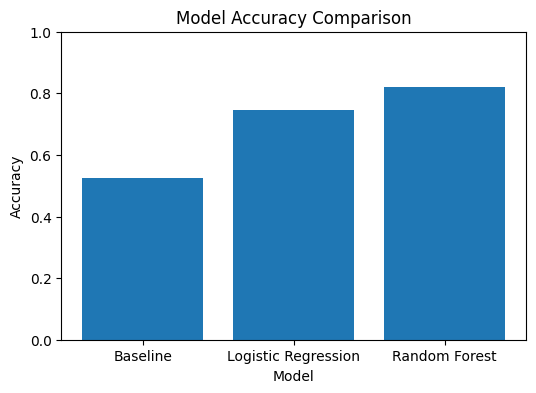

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

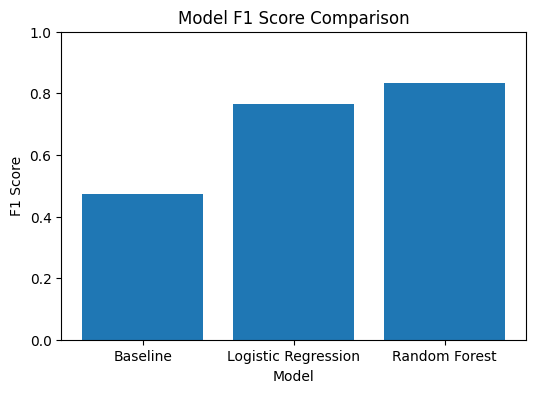

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0,1)

plt.show()

The Random Forest model consistently achieved the strongest performance across every evaluation metric and was therefore selected as the final model for the action playbook.

## 5. Limitations & Honest Framing

This study identifies patterns associated with declining content performance within the available dataset. The model is intended to support editorial decision-making by prioritizing content for review and should not be interpreted as evidence of causal relationships or guaranteed future outcomes.

The evaluation was performed using grouped client-level validation to reduce information leakage, but the results may not generalize to different datasets, organizations, or future content without additional validation. Changes in user behavior, business priorities, or content characteristics may also affect model performance over time.

Human judgment remains essential when acting on the model's recommendations. Editorial expertise, business context, and current content quality should always be considered before making decisions based on the action playbook.

In [ ]:
limitations = pd.DataFrame({
    "Aspect": [
        "Claim Type",
        "Primary Use",
        "Human Review",
        "Generalization"
    ],
    "Statement": [
        "Observational, not causal",
        "Decision support",
        "Required before action",
        "Requires validation on new data"
    ]
})

limitations

,Aspect,Statement
0,Claim Type,"Observational, not causal"
1,Primary Use,Decision support
2,Human Review,Required before action
3,Generalization,Requires validation on new data


## 6. Ranked Recommendations (Action Playbook)

The action playbook translates model predictions into a prioritized workflow for editorial teams. Content with the highest predicted decline probability is ranked first to help reviewers focus on pages that may benefit most from timely intervention.

Recommendations are grouped into three priority levels. High-priority pages should be reviewed immediately, medium-priority pages should be considered for content refresh, and low-priority pages should continue to be monitored. These recommendations are intended to support human decision-making and should always be reviewed alongside editorial judgment and business context.

In [ ]:
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("content_refresh_anonymized.csv")

df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

groups = df["client_id"]

X = df.drop(columns=[
    "content_id",
    "client_id",
    "provider_used",
    "model_used",
    "trend_direction",
    "trend_pct",
    "is_declining_label",
])

y = df["is_declining_label"]

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]

rf.fit(X_train, y_train)

decline_probability = rf.predict_proba(X_test)[:, 1]

action_queue = X_test.copy()

action_queue["Decline Probability"] = decline_probability

action_queue = action_queue.sort_values(
    "Decline Probability",
    ascending=False
)

action_queue["Priority"] = pd.cut(
    action_queue["Decline Probability"],
    bins=[0, 0.5, 0.8, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

action_queue["Recommended Action"] = action_queue["Priority"].map({
    "High": "Review immediately",
    "Medium": "Refresh content",
    "Low": "Monitor"
})

action_queue["Reason Code"] = action_queue["Priority"].map({
    "High": "High predicted decline risk",
    "Medium": "Moderate predicted decline risk",
    "Low": "Low predicted decline risk"
})

action_queue = action_queue[
    [
        "Priority",
        "Decline Probability",
        "Recommended Action",
        "Reason Code"
    ]
]

In [ ]:
action_queue.head(10)

,Priority,Decline Probability,Recommended Action,Reason Code
19110,High,0.99,Review immediately,High predicted decline risk
3329,High,0.99,Review immediately,High predicted decline risk
29681,High,0.98,Review immediately,High predicted decline risk
18822,High,0.98,Review immediately,High predicted decline risk
10171,High,0.98,Review immediately,High predicted decline risk
5410,High,0.98,Review immediately,High predicted decline risk
5353,High,0.97,Review immediately,High predicted decline risk
25063,High,0.97,Review immediately,High predicted decline risk
17707,High,0.97,Review immediately,High predicted decline risk
3211,High,0.97,Review immediately,High predicted decline risk


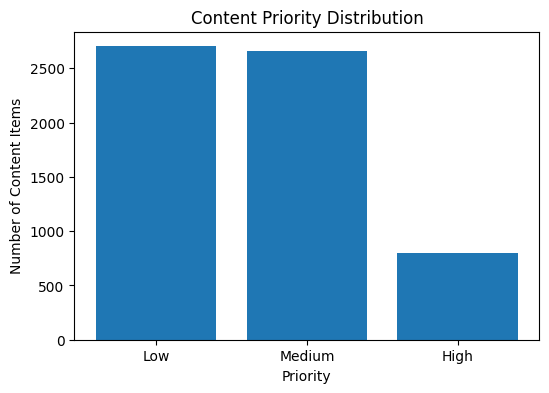

In [ ]:
priority_counts = action_queue["Priority"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(priority_counts.index, priority_counts.values)
plt.title("Content Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Content Items")
plt.show()

The action queue shows that the model distributes content across three priority levels, allowing reviewers to focus first on the highest-risk pages while continuing to monitor lower-risk content. This ranking supports a structured review process rather than treating all content equally.

The priority assignments are based on predicted decline probabilities observed in the available dataset and are intended to guide review efforts. Final editorial actions should always remain subject to human evaluation.

## 7. Reproducibility

This research was developed using the notebooks completed throughout the FlyRank ML Internship. Each stage of the workflow, from problem definition and data understanding to model development, validation, and action planning, is documented within the repository.

The complete project, including notebooks, code, and supporting files, is available in the accompanying GitHub repository. The experiments were implemented in Python using pandas and scikit-learn, with a fixed random seed to support reproducibility.

To reproduce the results, run the notebooks in sequence, beginning with the earlier research notebooks and continuing through the model development, validation audit, action playbook, and this capstone notebook. The dataset used in this project must be available before executing the notebooks.

In [ ]:
reproducibility = pd.DataFrame({
    "Item": [
        "Repository",
        "Programming Language",
        "Libraries",
        "Random Seed",
        "Core Notebooks"
    ],
    "Details": [
        "https://github.com/venkat-vipul/flyrank_ml",
        "Python",
        "pandas, scikit-learn, matplotlib",
        "42",
        "Research notebooks (Weeks 1–7) and Capstone notebook"
    ]
})

reproducibility

,Item,Details
0,Repository,https://github.com/venkat-vipul/flyrank_ml
1,Programming Language,Python
2,Libraries,"pandas, scikit-learn, matplotlib"
3,Random Seed,42
4,Core Notebooks,Research notebooks (Weeks 1–7) and Capstone no...


## 8. Acknowledgments & Data Credit

This project was completed as part of the FlyRank Machine Learning Internship.

The research was built on the **FlyRank ML Internship dataset**, which provided anonymized production-derived search data for educational and research purposes.

Data Credit: https://flyrank.ai

The author would like to acknowledge FlyRank for providing the dataset, learning materials, and project framework that made this research possible.

This paper contains only public-safe descriptions and does not disclose client names, domains, URLs, private queries, or other sensitive production information.

In [ ]:
acknowledgments = pd.DataFrame({
    "Item": [
        "Organization",
        "Dataset",
        "Project",
        "Data Credit"
    ],
    "Details": [
        "FlyRank",
        "FlyRank ML Internship Dataset",
        "Machine Learning Internship",
        "https://flyrank.ai"
    ]
})

acknowledgments

,Item,Details
0,Organization,FlyRank
1,Dataset,FlyRank ML Internship Dataset
2,Project,Machine Learning Internship
3,Data Credit,https://flyrank.ai


# Week 8 Showcase Demo Outline

## Question (45 seconds)

How can machine learning help identify content that is likely to experience declining performance before manual review?

---

## Method (1.5 minutes)

- Built a supervised machine learning pipeline using the FlyRank ML Internship dataset.
- Removed potential data leakage features and identifier columns.
- Used GroupShuffleSplit to ensure grouped validation and prevent client-level leakage.
- Compared a baseline classifier, Logistic Regression, and Random Forest using Accuracy, Precision, Recall, and F1-score.

---

## One Key Result (1 minute)

Random Forest achieved the strongest overall performance with:

- Accuracy: **82.07%**
- Precision: **79.69%**
- Recall: **87.11%**
- F1-score: **0.8323**

This represents a substantial improvement over the baseline while maintaining balanced classification performance.

---

## One Chart (1 minute)

Present the **F1 Score Comparison** chart from the Results section to demonstrate the performance difference between the Baseline, Logistic Regression, and Random Forest models.

---

## Recommendation (45 seconds)

The trained model can be used to prioritize editorial review by ranking content according to predicted decline probability. High-priority pages should be reviewed first, while final editorial decisions remain with human experts. This makes the workflow faster, more consistent, and data-driven without replacing human judgment.

---

# Social Media Post

Completed my FlyRank ML Internship capstone by building a machine learning pipeline to identify declining content performance using grouped validation and leakage-aware evaluation. I compared multiple classification models and found that Random Forest delivered the strongest overall performance, achieving an F1-score of **0.8323**. The project demonstrates how reproducible machine learning workflows can support editorial decision-making while keeping humans responsible for final content decisions.

---

# Employer Summary

Built a machine learning pipeline using the FlyRank ML Internship dataset to predict declining content performance. Implemented leakage prevention, grouped validation, and evaluated multiple classification models, with Random Forest achieving the strongest overall performance. The project demonstrates how predictive analytics can support editorial prioritization through reproducible, data-driven decision support while maintaining human oversight.